In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.precision', 3)

In [2]:
# Extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox, norm
from statsmodels.genmod.generalized_linear_model import GLM

In [3]:
import warnings
warnings.filterwarnings('ignore')

# 1. Analyzing the dataset

[YAPPING]

In [4]:
raw_data = read_csv("train_features_ILDS.csv", delimiter = ',', header = None)
raw_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
raw_data['Target'] = read_csv("train_labels_ILDS.csv", delimiter=',', header = None)
raw_data['Female'] = raw_data['Female'].astype('category')
raw_data['Target'] = raw_data['Target'].astype('category')

raw_data.shape #tamany

(463, 11)

In [5]:
raw_data.head()

,Age,Female,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,Target
0,40,0,3.9,1.7,350,950,1500,6.7,3.8,1.30,0
1,48,0,4.5,2.3,282,13,74,7.0,2.4,0.52,0
2,39,0,1.9,0.9,180,42,62,7.4,4.3,1.38,0
3,23,0,1.0,0.3,212,41,80,6.2,3.1,1.00,0
4,42,1,0.7,0.2,152,35,81,6.2,3.2,1.06,0


In [6]:
raw_data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR
count,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000
mean,44.881,3.279,1.446,279.866,75.844,97.607,6.422,3.110,0.943
std,16.309,6.115,2.675,211.283,169.290,212.114,1.052,0.793,0.318
min,4.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,176.000,23.000,25.000,5.700,2.500,0.700
50%,45.000,1.000,0.300,208.000,34.000,41.000,6.500,3.100,0.920
75%,57.500,2.700,1.300,291.000,60.000,83.500,7.100,3.700,1.100
max,90.000,75.000,18.300,1630.000,2000.000,2946.000,9.500,5.500,2.800


In [7]:
print(raw_data[raw_data['Female'] == 1]['Target'].value_counts())
print(raw_data[raw_data['Female'] == 0]['Target'].value_counts())

Target
0    74
1    38
Name: count, dtype: int64
Target
0    257
1     94
Name: count, dtype: int64


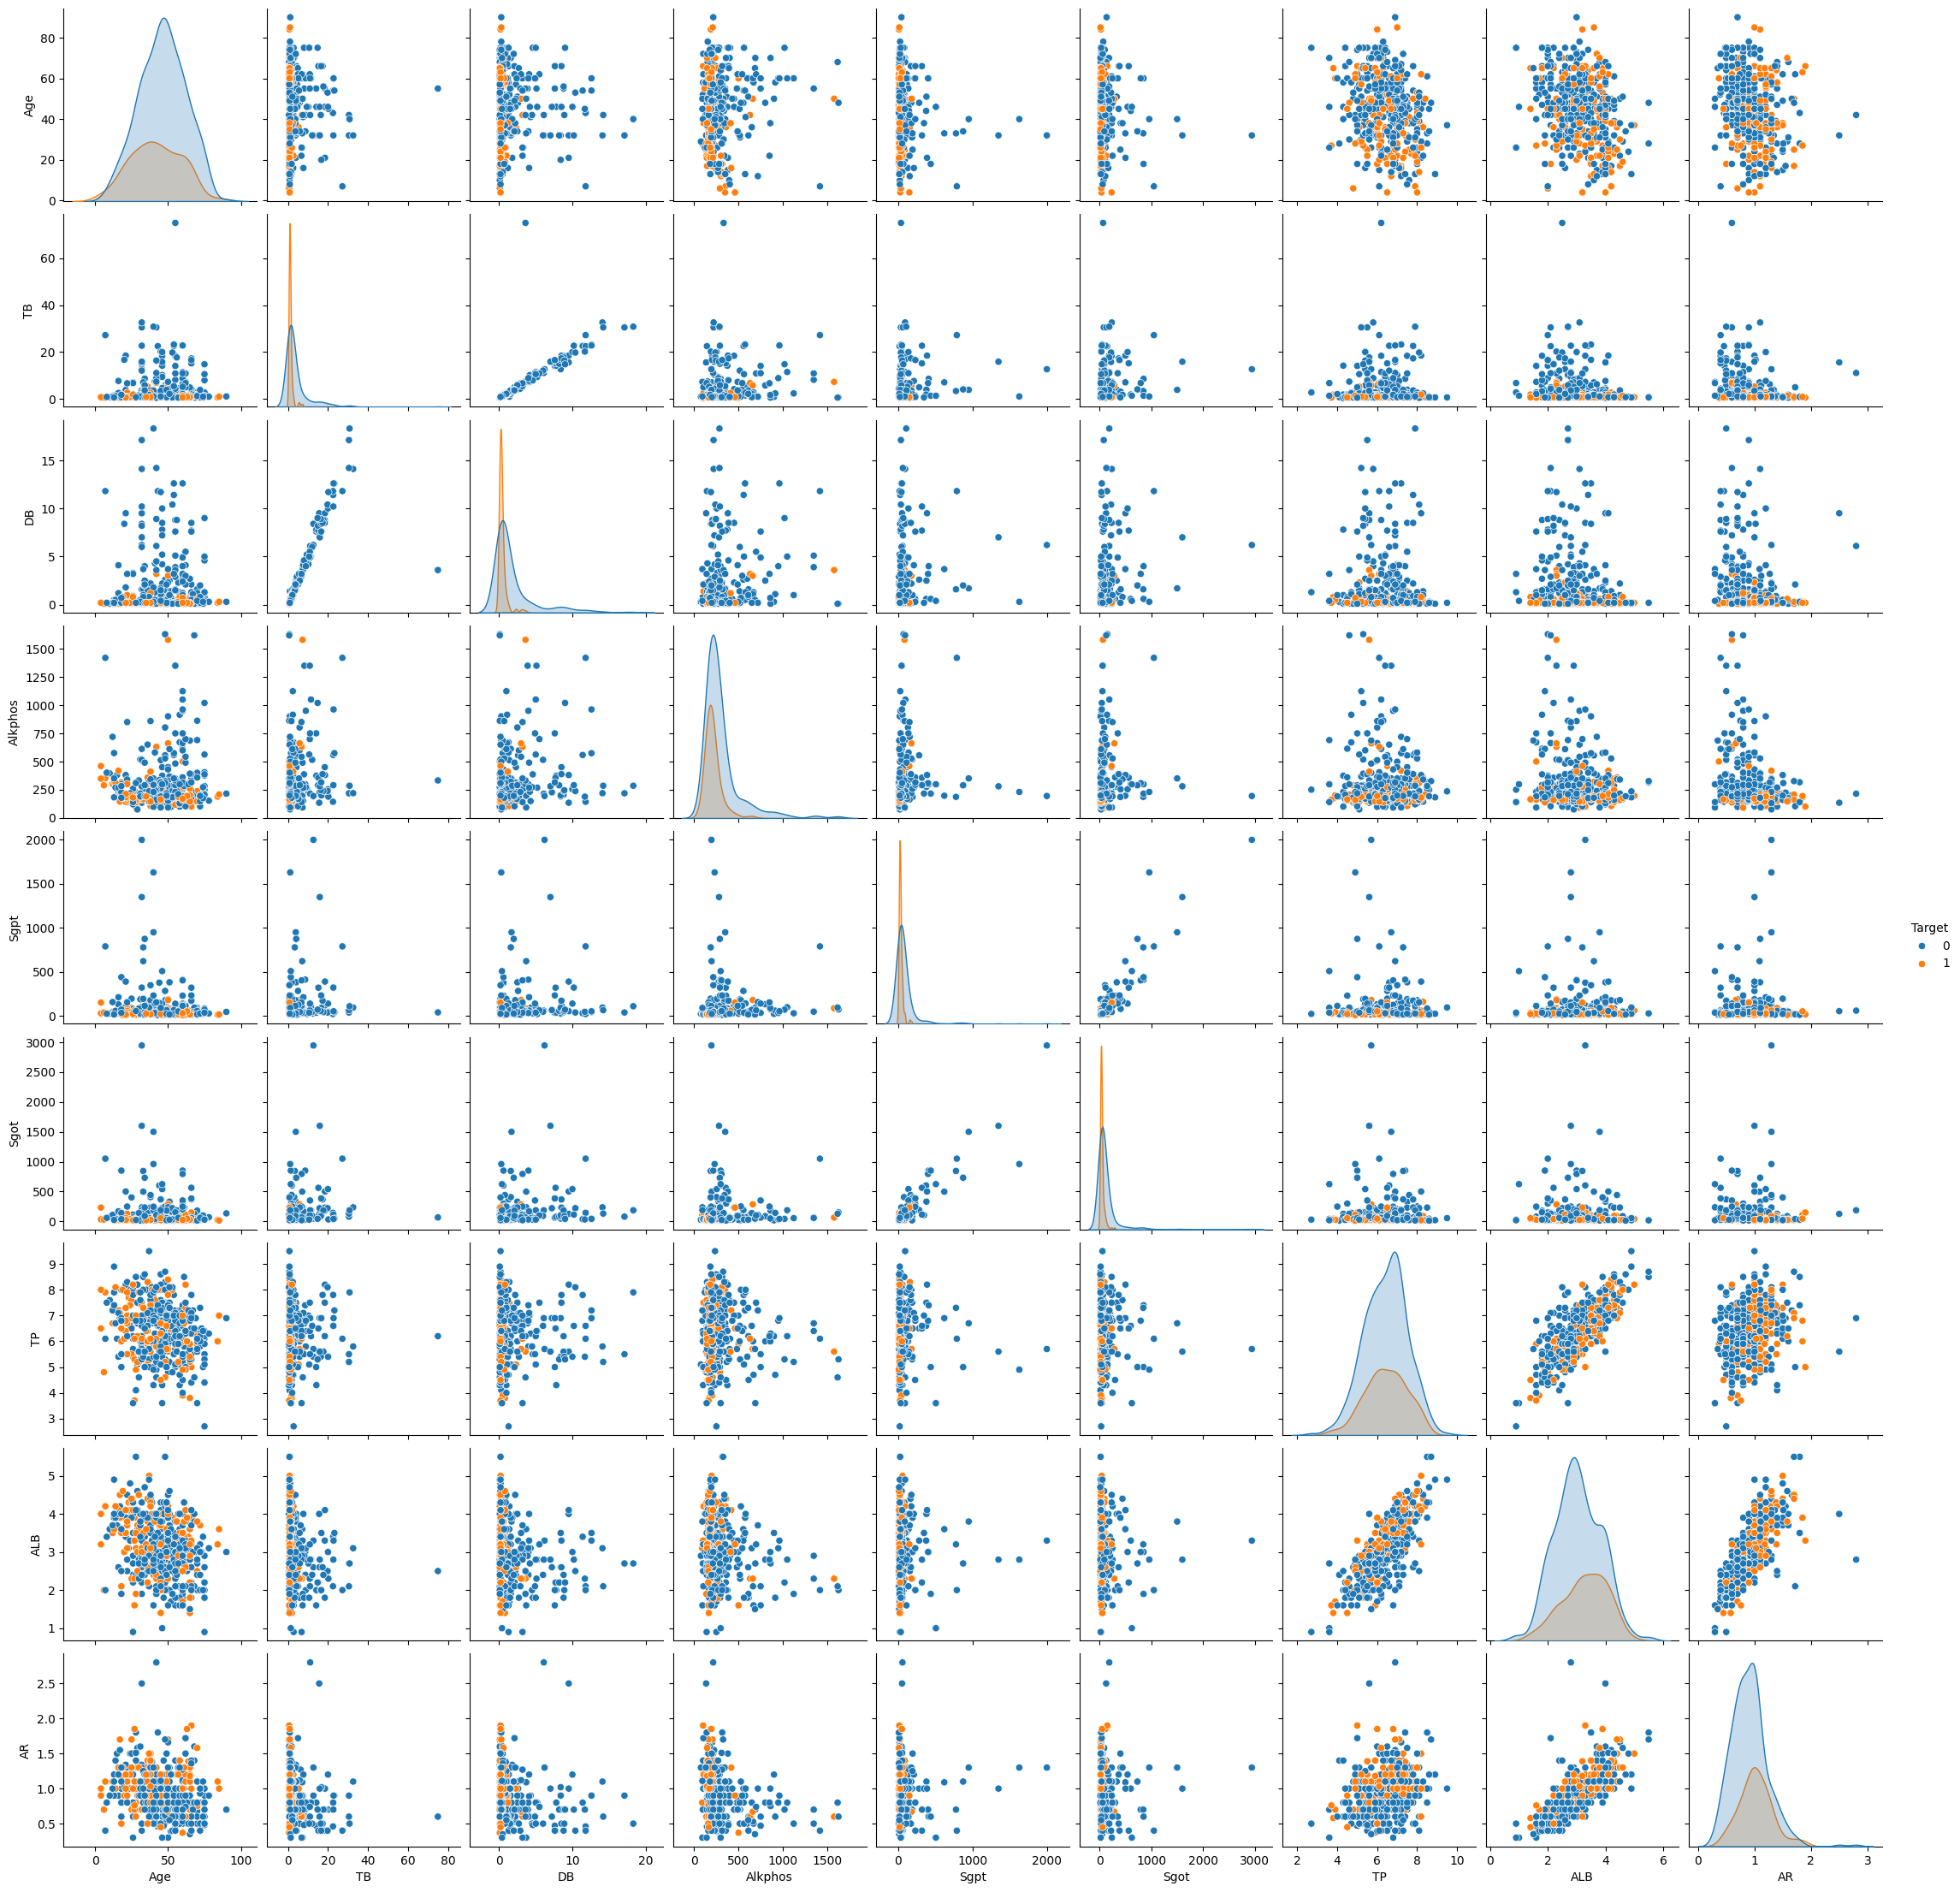

In [8]:
sns.pairplot(raw_data, hue = "Target")

In [9]:
raw_numdata = raw_data.drop(columns = ["Female", "Target"])
corr = raw_numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = raw_numdata @ U

print(eigs)
print(X_pca.shape)

[2.82463156 2.10174352 1.43118055 0.84093437 0.88460761 0.63952997
 0.044745   0.0830351  0.14959234]
(463, 9)


<Figure size 600x400 with 0 Axes>

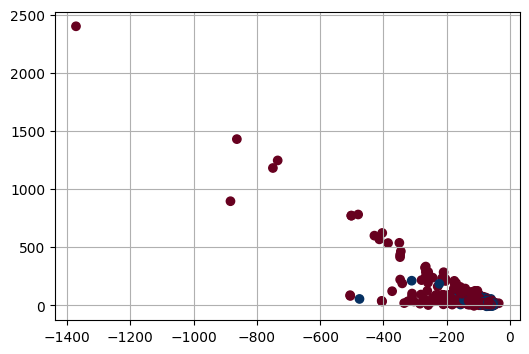

In [10]:
x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = raw_data['Target'], cmap = "RdBu")
_ = plt.grid()

In [11]:
sick_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 0]
corr = sick_numdata.corr()

eigs, U = np.linalg.eig(corr) 
sick_pca = sick_numdata @ U

print(eigs)
print(sick_pca.shape)

[2.72097017 2.14208179 1.47309362 0.90460943 0.79655931 0.66467459
 0.15957238 0.05497367 0.08346502]
(331, 9)


<Figure size 600x400 with 0 Axes>

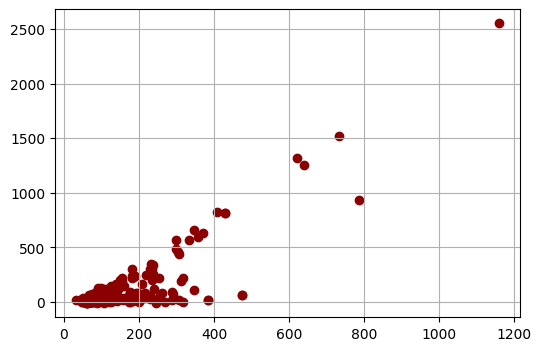

In [12]:
x = sick_pca.loc[:, 0]
y = sick_pca.loc[:, 1]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkred")
_ = plt.grid()

In [13]:
healthy_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 1]
corr = healthy_numdata.corr()

eigs, U = np.linalg.eig(corr) 
healthy_pca = healthy_numdata @ U

print(eigs)
print(healthy_pca.shape)

[3.31745296 2.18729537 1.13108032 1.00219726 0.65735369 0.41528247
 0.26302742 0.01553821 0.0107723 ]
(132, 9)


<Figure size 600x400 with 0 Axes>

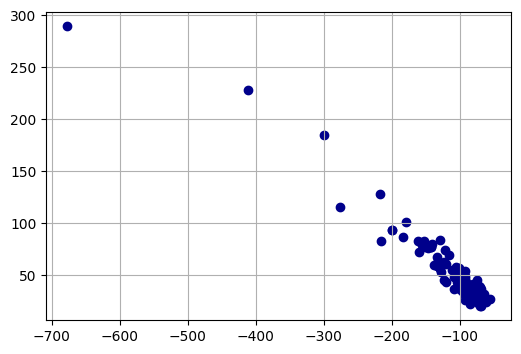

In [14]:
x = healthy_pca.loc[:, 0]
y = healthy_pca.loc[:, 1]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkblue")
_ = plt.grid()

# 2. Identifying anomalies through PCA

First of all, we have found clear anormal individuals (healthy and sick) which we should eliminate. Not eliminating them can be problematic when fitting the models or if we want to do resampling.

We remove 5 outliers from our sick patients:

In [15]:
sick_data = raw_data[raw_data['Target'] == 0]
healthy_data = raw_data[raw_data['Target'] == 1]

sick_data = sick_data[sick_pca.loc[:, 0] <= 600]
healthy_data = healthy_data[healthy_pca.loc[:, 1] <= 150]

data_v1 = pd.concat([sick_data, healthy_data], axis = 0)
data_v1.shape
data_v1.describe()

(455, 11)

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR
count,455.000,455.000,455.000,455.000,455.000,455.000,455.000,455.000,455.000
mean,45.110,3.172,1.397,273.413,61.484,80.343,6.432,3.115,0.943
std,16.212,6.013,2.628,195.895,95.195,120.652,1.056,0.795,0.318
min,4.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,175.500,22.500,25.000,5.700,2.550,0.700
50%,45.000,1.000,0.300,206.000,33.000,41.000,6.500,3.100,0.920
75%,58.000,2.600,1.200,290.000,58.000,79.500,7.100,3.750,1.100
max,90.000,75.000,18.300,1630.000,875.000,850.000,9.500,5.500,2.800


[2.82497774 2.00315451 1.41047271 0.92204875 0.83086335 0.65465019
 0.04464246 0.14661052 0.16257977]
(455, 9)


<Figure size 600x400 with 0 Axes>

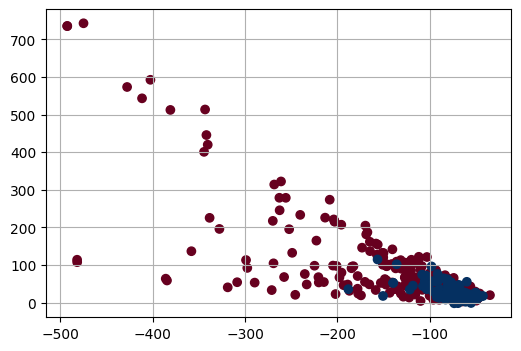

In [16]:
numdata_v1 = data_v1.drop(columns = ["Female", "Target"])
corr = numdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = numdata_v1 @ U

print(eigs)
print(X_pca.shape)

x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = data_v1['Target'], cmap = "RdBu")
_ = plt.grid()

[2.73153164 2.01354903 1.47189865 0.93889552 0.78849148 0.6808072
 0.05506711 0.14912681 0.17063257]
(326, 9)


<Figure size 600x400 with 0 Axes>

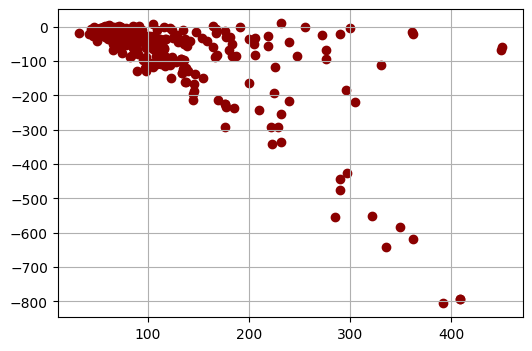

In [17]:
sicknumdata_v1 = numdata_v1[data_v1['Target'] == 0]
corr = sicknumdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
sick_pca = sicknumdata_v1 @ U

print(eigs)
print(sick_pca.shape)

x = sick_pca.loc[:, 0]
y = sick_pca.loc[:, 1]
z = sick_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkred")
_ = plt.grid()

[2.66169106 2.16538989 1.21004531 1.18370869 0.81044446 0.451213
 0.48495229 0.01562661 0.01692869]
(129, 9)


<Figure size 600x400 with 0 Axes>

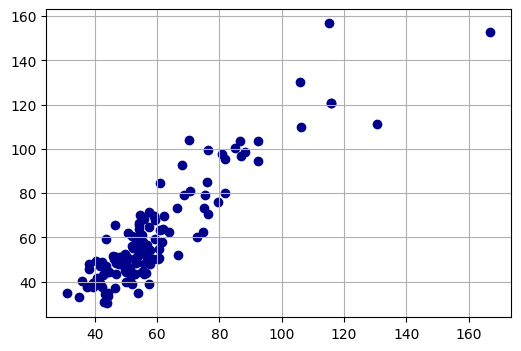

In [18]:
healthynumdata_v1 = numdata_v1[data_v1['Target'] == 1]
corr = healthynumdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
healthy_pca = healthynumdata_v1 @ U

print(eigs)
print(healthy_pca.shape)

x = healthy_pca.loc[:, 0]
y = healthy_pca.loc[:, 1]
z = healthy_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkblue")
_ = plt.grid()

# 3. First feature extraction

We extract a few features which might be useful. We will later extract more features while doing feature selection, but for now let's focus on these ones.

## Indirect Bilirubin

The difference between total bilirubin and direct bilirubin. A high level of indirect bilirubin might indicate possible liver disease.

In [19]:
data_v1['IB'] = data_v1.TB - data_v1.DB

## Direct / Total Ratio

Another variable derived from DB and TB that shows the ratio between the direct bilirubin and the total bilirubin. This might help make better decisions in some cases.

In [20]:
data_v1['DBRatio'] = data_v1.DB / data_v1.TB
data_v1['IBRatio'] = data_v1.IB / data_v1.TB

## AST / ALT Ratio

In [21]:
data_v1['AST_ALT_Ratio'] = data_v1.Sgot / data_v1.Sgpt

## ALBI Score

In [22]:
data_v1['ALBIScore'] = 0.66 * np.log10(data_v1.TB) - 0.0852 * data_v1.ALB 

## Globulin

In [23]:
data_v1['Glob'] = data_v1.ALB / data_v1.AR

# 4. Individual look at each variable

Now we will take a look at variables separately, with the use of histograms and boxplots.

In [24]:
def histbox (data, column: str, n_bins: int = 10) -> None:
    fig, axes = plt.subplots(1, 2, gridspec_kw = {'width_ratios': [1, 4]}, figsize=(9,4))
    sns.boxplot(data = data, x = 'Target', y = column, hue = 'Target', ax = axes[0])
    
    sick = data[data["Target"] == 0]
    healthy = data[data["Target"] == 1]
    mean_sick = np.mean(sick[column])
    mean_healthy = np.mean(healthy[column])
    std_sick = np.std(sick[column])
    std_healthy = np.std(healthy[column])
    prop_sick = len(sick) / len(data)
    prop_healthy = len(healthy) / len(data)
    
    x = np.linspace(np.min(sick[column]), np.max(sick[column]), num = 500)
    y = np.linspace(np.min(healthy[column]), np.max(healthy[column]), num = 500)
    ax = sns.histplot(data = data, x = column, hue = 'Target', ax = axes[1],
                      bins = n_bins, stat = "density")
    ax.plot(x, norm.pdf(x, loc = mean_sick, scale = std_sick) * prop_sick)
    ax.plot(y, norm.pdf(y, loc = mean_healthy, scale = std_healthy) * prop_healthy)

In [25]:
data_v1.columns

Index(['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'AR', 'Target', 'IB', 'DBRatio', 'IBRatio', 'AST_ALT_Ratio',
       'ALBIScore', 'Glob'],
      dtype='object')

In [26]:
data_v2 = data_v1.copy()

## Age

Not much to say here, as it appears that a normal distribution is followed for both classes.

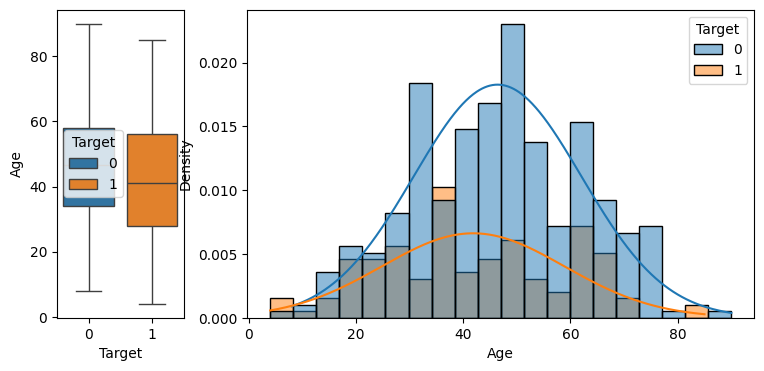

In [27]:
histbox(data_v1, "Age", 20)

## Bilirubin-related variables

Total, Indirect and Direct Bilirubin variables require some kind of logarithmic transformation in order to approximate them to a normal distribution.

We have decided not to transform the ratio variables.

There is an observation with a negative number of indirect bilirubin! In theory this should be impossible, so we have removed this individual.

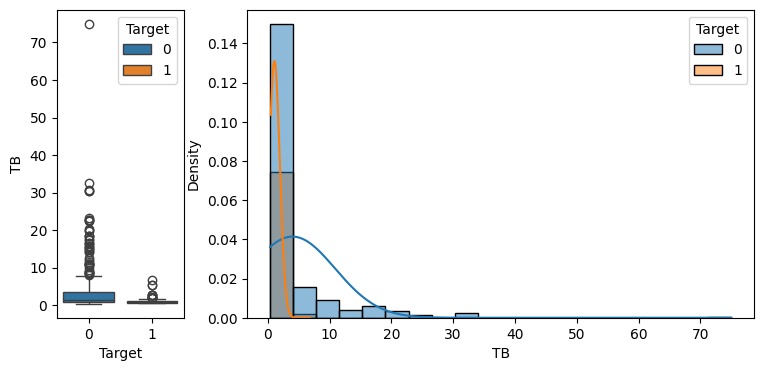

In [28]:
histbox(data_v1, "TB", 20)

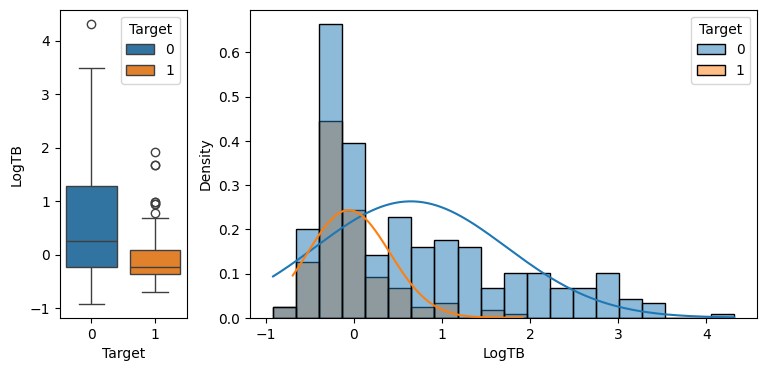

In [29]:
data_v2 = data_v2.drop(columns = "TB")
data_v2["LogTB"] = np.log(data_v1.TB)
histbox(data_v2, "LogTB", 20)

In [30]:
print(data_v2.shape)
data_v2 = data_v2[data_v2["LogTB"] < 4]
print(data_v2.shape)

(455, 17)
(454, 17)


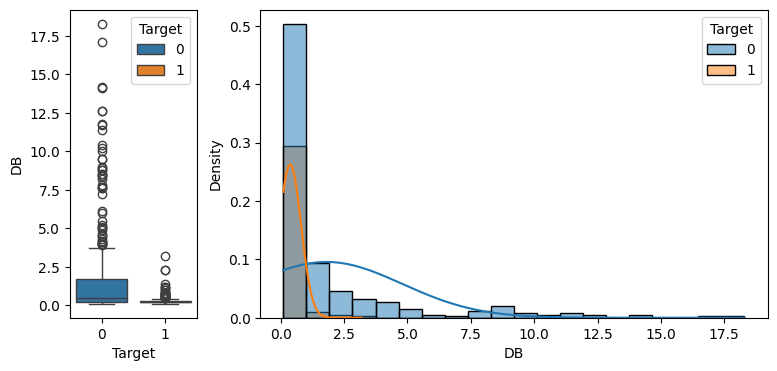

In [31]:
histbox(data_v1, "DB", 20)

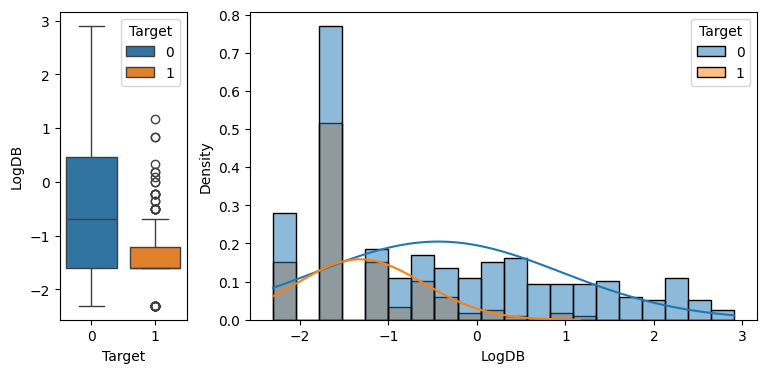

In [32]:
data_v2 = data_v2.drop(columns = "DB")
data_v2["LogDB"] = np.log(data_v1.DB)
histbox(data_v2, "LogDB", 20)

There is a value of the Indirect Bilirubin that is negative; this shouldn't be possible, so we are going to eliminate that individual.

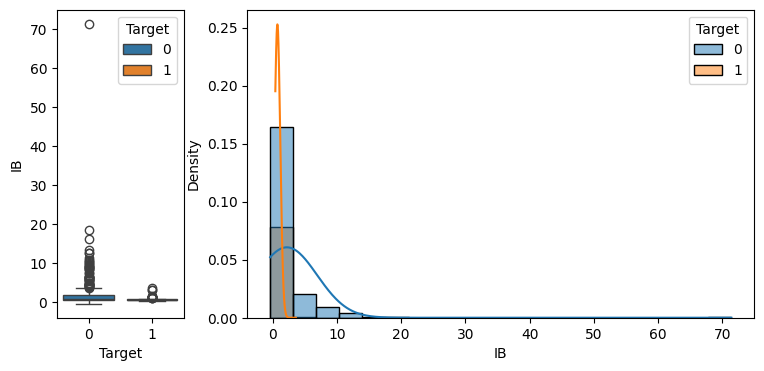

In [33]:
histbox(data_v1, "IB", 20)

In [34]:
print(data_v2.shape)
data_v2 = data_v2[data_v2.IB >= 0]
print(data_v2.shape)

(454, 17)
(453, 17)


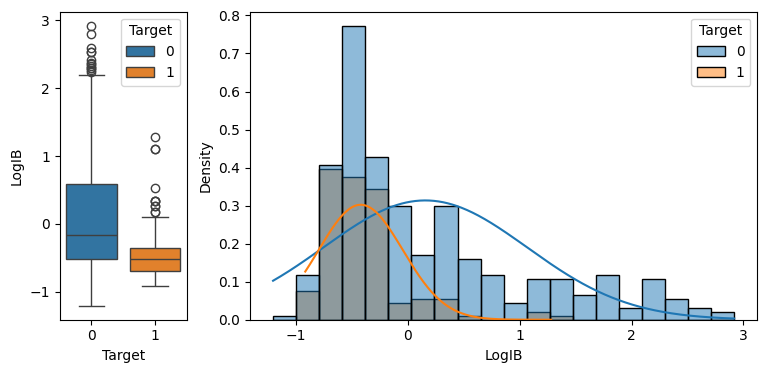

In [35]:
data_v2 = data_v2.drop(columns = "IB")
data_v2["LogIB"] = np.log(data_v1.IB)
histbox(data_v2, "LogIB", 20)

The ratio variables have not been transformed. The 1.4 ratio visible here corresponds to the individual with higher direct bilirubin than total bilirubin which we have already discarded.

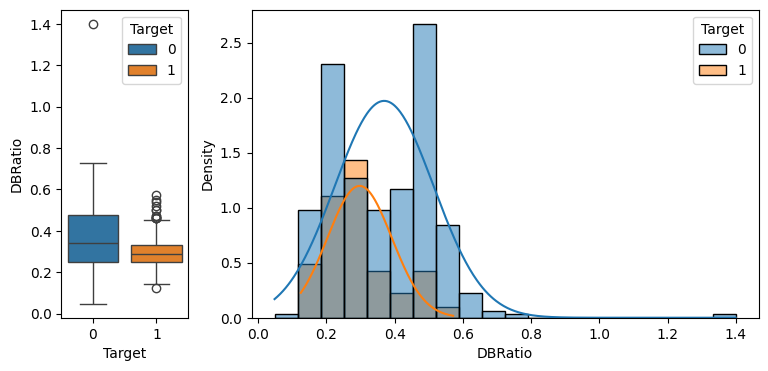

In [36]:
histbox(data_v1, "DBRatio", 20)

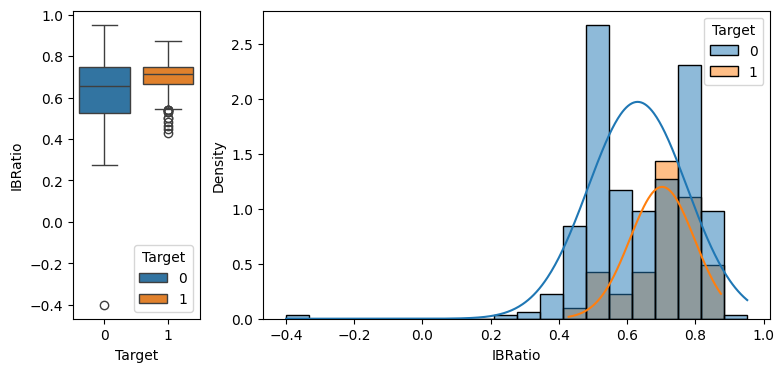

In [37]:
histbox(data_v1, "IBRatio", 20)

# Alkphos

A logarithmic transformation would be suitable here.

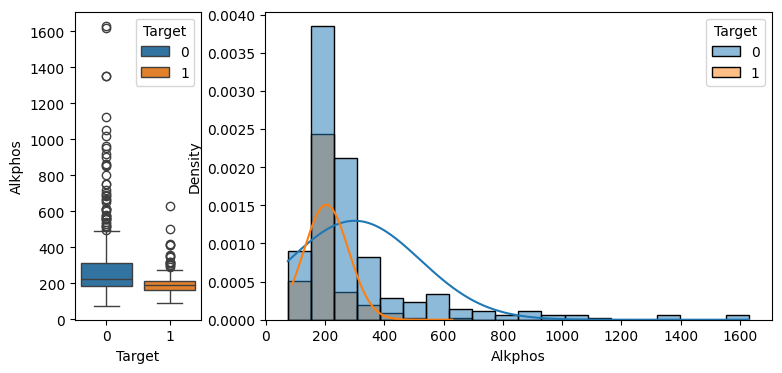

In [38]:
histbox(data_v1, "Alkphos", 20)

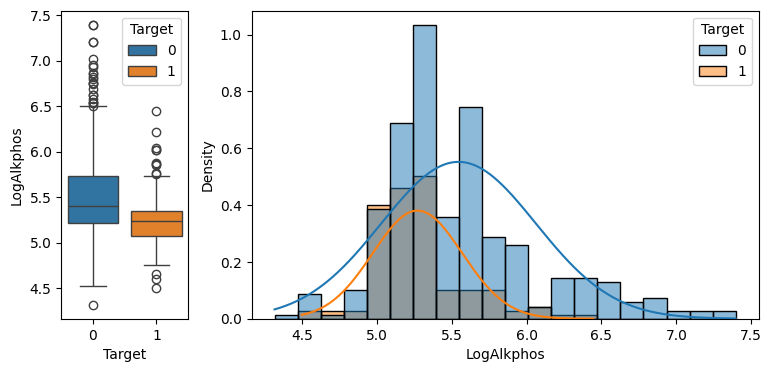

In [39]:
data_v2 = data_v2.drop(columns = "Alkphos")
data_v2["LogAlkphos"] = np.log(data_v1.Alkphos)
histbox(data_v2, "LogAlkphos", 20)

## AST / ALT

Logarithmic transformations are suitable for both Sgpt and Sgot.

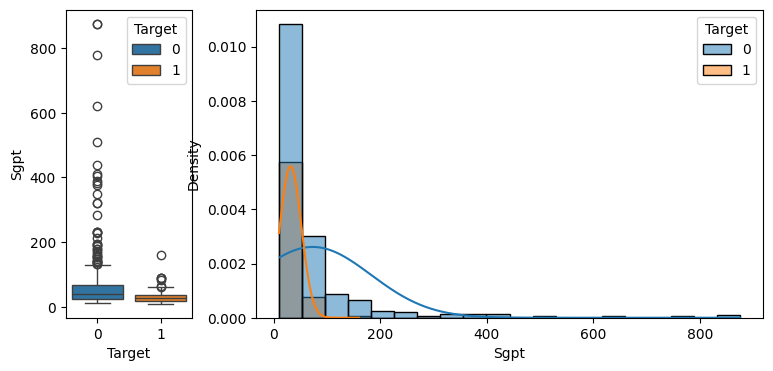

In [40]:
histbox(data_v1, "Sgpt", 20)

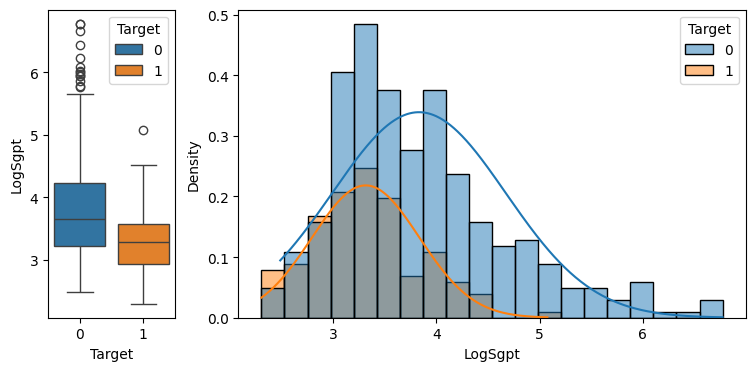

In [41]:
data_v2 = data_v2.drop(columns = "Sgpt")
data_v2["LogSgpt"] = np.log(data_v1.Sgpt)
histbox(data_v2, "LogSgpt", 20)

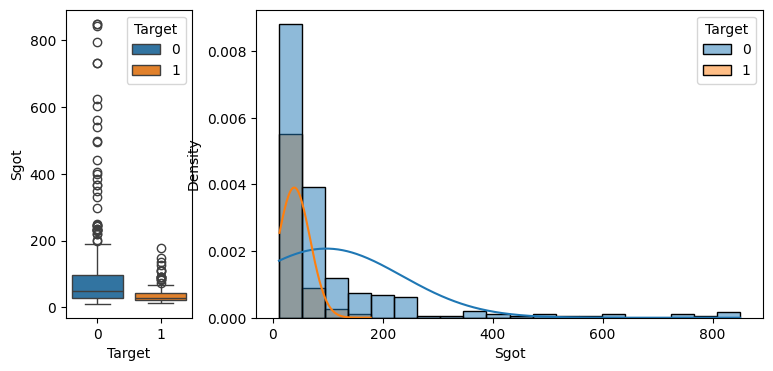

In [42]:
histbox(data_v1, "Sgot", 20)

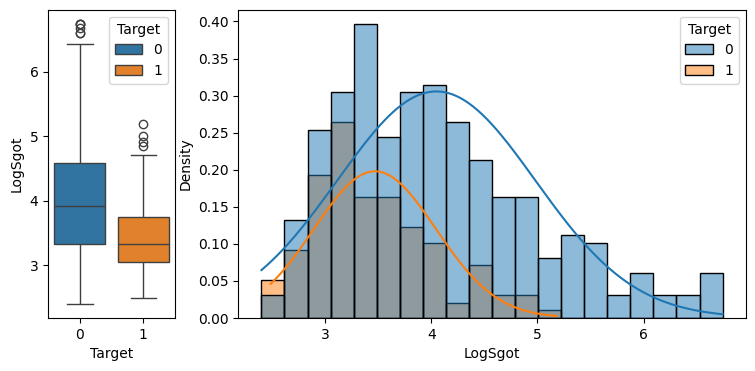

In [43]:
data_v2 = data_v2.drop(columns = "Sgot")
data_v2["LogSgot"] = np.log(data_v1.Sgot)
histbox(data_v2, "LogSgot", 20)

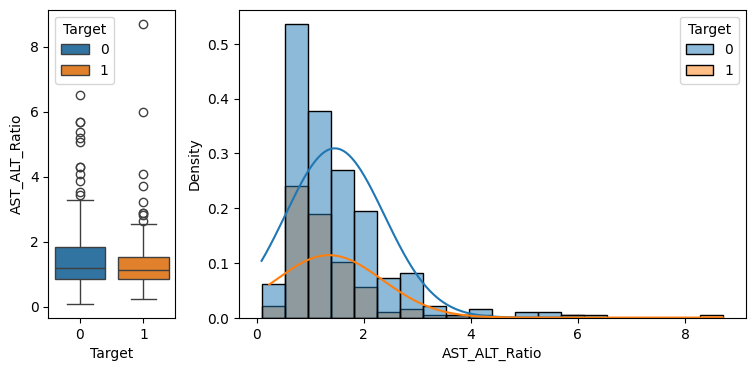

In [44]:
histbox(data_v1, "AST_ALT_Ratio", 20)

In [45]:
print(data_v2.shape)
data_v2 = data_v2[data_v2.AST_ALT_Ratio < 8]
print(data_v2.shape)

(453, 17)
(452, 17)


## Proteins

The total amount of protein follows a seemingly normal distribution, as well as the other variables.

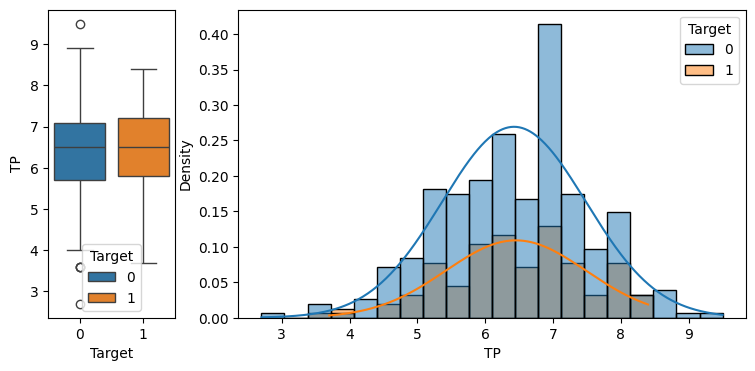

In [46]:
histbox(data_v1, "TP", 20)

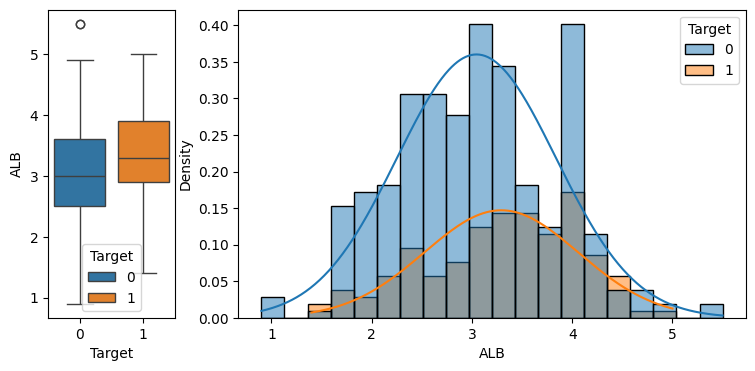

In [47]:
histbox(data_v1, "ALB", 20)

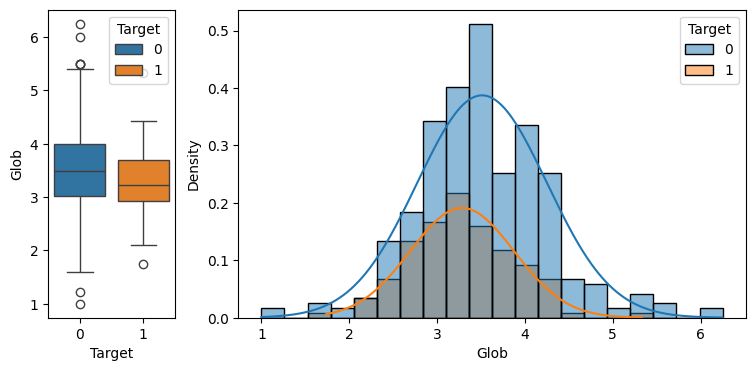

In [48]:
histbox(data_v1, "Glob", 20)

We have removed some outliers by observing the Albumin / Globulin ratio.

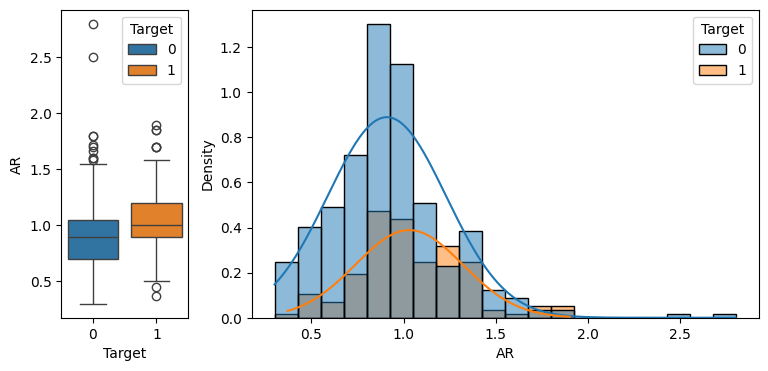

In [49]:
histbox(data_v1, "AR", 20)

In [50]:
(data_v2["AR"] < 2).value_counts()
data_v2 = data_v2[data_v2["AR"] < 2]

AR
True     450
False      2
Name: count, dtype: int64

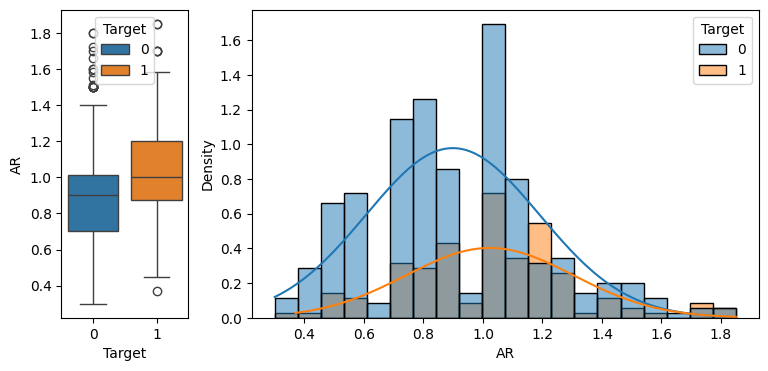

In [51]:
histbox(data_v2, "AR", 20)

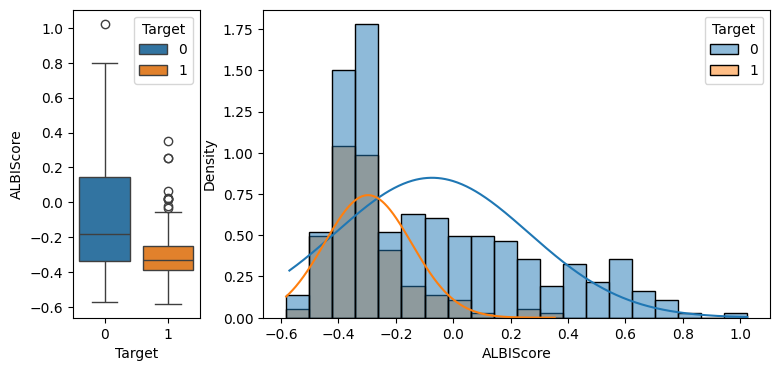

In [52]:
histbox(data_v1, "ALBIScore", 20)

In [53]:
(data_v2["Target"] == 1).value_counts()

Target
False    322
True     128
Name: count, dtype: int64

In [54]:
data_v2.describe()

,Age,TP,ALB,AR,DBRatio,IBRatio,AST_ALT_Ratio,ALBIScore,Glob,LogTB,LogDB,LogIB,LogAlkphos,LogSgpt,LogSgot
count,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000,450.000
mean,45.071,6.432,3.112,0.934,0.346,0.654,1.406,-0.141,3.457,0.432,-0.699,-0.013,5.471,3.683,3.874
std,16.252,1.055,0.796,0.295,0.126,0.126,0.883,0.307,0.691,0.982,1.294,0.831,0.481,0.801,0.886
min,4.000,2.700,0.900,0.300,0.125,0.273,0.090,-0.582,1.221,-0.916,-2.303,-1.204,4.317,2.303,2.398
25%,33.000,5.700,2.525,0.700,0.250,0.539,0.836,-0.365,3.000,-0.223,-1.609,-0.511,5.170,3.135,3.219
50%,45.000,6.500,3.100,0.900,0.300,0.700,1.156,-0.273,3.402,0.000,-1.204,-0.357,5.333,3.497,3.701
75%,58.000,7.100,3.700,1.100,0.461,0.750,1.722,0.018,3.910,0.916,0.182,0.336,5.670,4.060,4.366
max,90.000,9.500,5.500,1.850,0.727,0.875,6.500,0.801,6.250,3.484,2.907,2.918,7.396,6.774,6.745


# 5. Steps that must be done in cross-validation

We need to scale our variables so that they are all zero mean, unit variance for the use of multiple models that might have numerical issues with non-standardized data. However, we must do this in cross-validation, or there may be data leaks during the cross-validation process.

If we want to use any oversampling / undersampling technique on the dataset, we would also need to do it on cross-validation, or we will get bad estimates of our generalization error.

# 6. Feature selection

We may benefit from reducing dimension. We have a lot of dimensions in PCA which hold very small amounts of variability, but they might still be relevant. We can try to reduce dimensionality by removing variables or non-important principal components. This should make our models more stable.

For this purpose, we standardize the data, but only so that numerical results such as mutual information are well computed.

In [55]:
from sklearn.feature_selection import r_regression
from sklearn.preprocessing import StandardScaler

data_v3 = data_v2.copy()

data_v3_num = data_v3.drop(columns = ["Female", "Target"])
p = data_v3_num.shape[1]
names = data_v3_num.columns

In [56]:
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data_v3_num),
                           columns = data_v3_num.columns)

Correlations between variables:

- The logarithms of the bilirubin variables (total, direct, indirect) are extremely correlated, and the ratios are equivalent (one is the complement of the other). Removing two of the three first variables and one of the ratios is almost necessary.

- 

<Axes: >

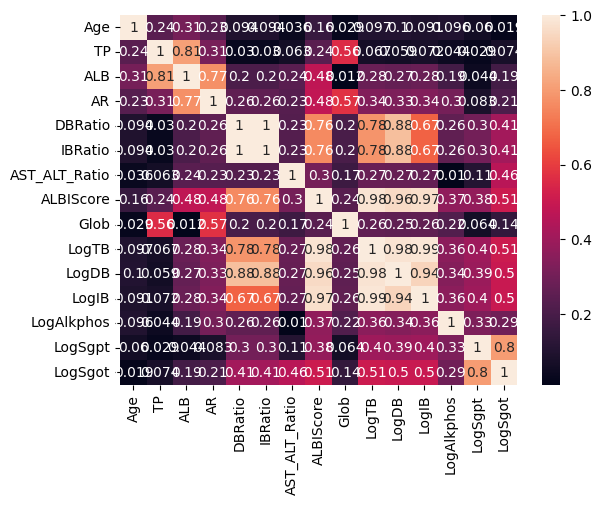

In [57]:
pearson = np.ndarray(shape = (p, p))
for i, col in enumerate(names):
    pearson[i, :] = r_regression(scaled_data, scaled_data[col])
pearson = pd.DataFrame(pearson, columns = names, index = names)

sns.heatmap(np.abs(pearson), annot = True)

Since the correlation in a lot of these variables comes from the use of the logarithmic scale, we can attempt to recover these variables to their original state. This might be worse for models that assume gaussian distributions and for scaling but might allows us to use some features more efficiently.

But if we try to do it, we see that they are actually even more correlated this way. So we will keep using the logarithm of these variables.

In [58]:
data_v4 = data_v3.drop(columns = ["LogTB", "LogDB", "LogIB", "IBRatio", "LogSgpt", "LogSgot", "Female", "Target"])
data_v4['TB'] = np.exp(data_v3.LogTB)
data_v4['DB'] = np.exp(data_v3.LogDB)
data_v4['IB'] = np.exp(data_v3.LogIB)
data_v4['Sgpt'] = np.exp(data_v3.LogSgpt)
data_v4['Sgot'] = np.exp(data_v3.LogSgot)

scaler = StandardScaler()
scaled_data_v4 = pd.DataFrame(scaler.fit_transform(data_v4),
                           columns = data_v4.columns)

<Axes: >

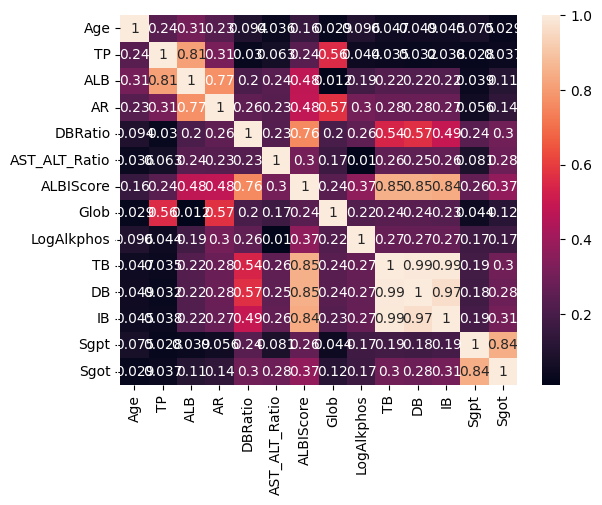

In [59]:
names = scaled_data_v4.columns
p = scaled_data_v4.shape[1]

pearson = np.ndarray(shape = (p, p))
for i, col in enumerate(names):
    pearson[i, :] = r_regression(data_v4, data_v4[col])
pearson = pd.DataFrame(pearson, columns = names, index = names)

sns.heatmap(np.abs(pearson), annot = True)

We can also obtain an approximated information matrix to gauge how much information about the target variable we obtain from our variables.

In [60]:
data_v3.columns

Index(['Age', 'Female', 'TP', 'ALB', 'AR', 'Target', 'DBRatio', 'IBRatio',
       'AST_ALT_Ratio', 'ALBIScore', 'Glob', 'LogTB', 'LogDB', 'LogIB',
       'LogAlkphos', 'LogSgpt', 'LogSgot'],
      dtype='object')

In [61]:
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression

data_v3_notarget = data_v3.drop(columns = "Target")

n = 1000
p = data_v3_notarget.shape[1]
mi = 0
for _ in range(n):
    mi += mutual_info_regression(data_v3_notarget, data_v3.Target, n_neighbors = 3)
mi = mi / n

columns = ['Age', 'Female', 'TP', 'ALB', 'AR', 'DBRatio', 'IBRatio',
       'AST_ALT_Ratio', 'ALBIScore', 'Glob', 'LogTB', 'LogDB', 'LogIB',
       'LogAlkphos', 'LogSgpt', 'LogSgot']
Imatt = pd.DataFrame(data = mi.reshape((1, p)), columns = columns)

In [62]:
Imatt

,Age,Female,TP,ALB,AR,DBRatio,IBRatio,AST_ALT_Ratio,ALBIScore,Glob,LogTB,LogDB,LogIB,LogAlkphos,LogSgpt,LogSgot
0,0.04,0.014,0.003,0.028,0.021,0.059,0.059,0.007,0.108,0.038,0.061,0.058,0.07,0.045,0.059,0.072


<Axes: >

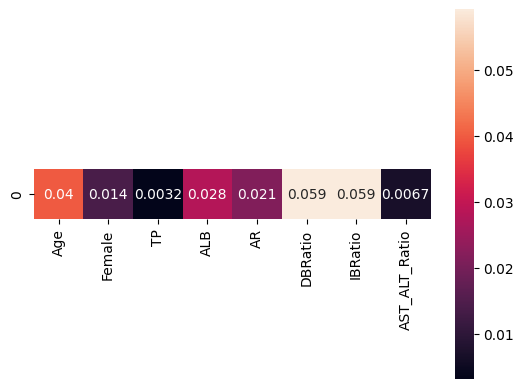

In [63]:
sns.heatmap(Imatt.iloc[:, 0:p//2], annot = True, square = True)

<Axes: >

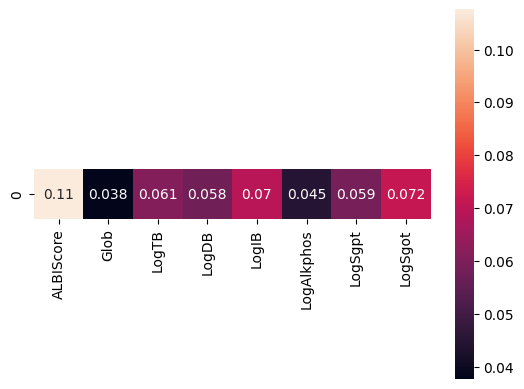

In [64]:
sns.heatmap(Imatt.iloc[:, p//2:p], annot = True, square = True)

In [65]:
data_v3_notarget.shape[1]

16

What we propose is to remove the Total Protein, Total Bilirubin, the Indirect Bilirubin ratio and AST/ALT Ratio variables due to their high correlation with other variables.

In [66]:
def plot_PCA (X: np.ndarray, target: np.ndarray,
              axes: tuple[int, int, int] = (0, 1, 2), plot_3D: bool = True) -> np.ndarray:
    corr = X.corr()

    eigs, U = np.linalg.eig(corr) 
    X_pca = X @ U

    print(eigs)
    print(X_pca.shape)

    x = X_pca.loc[:, axes[0]]
    y = X_pca.loc[:, axes[1]]
    z = X_pca.loc[:, axes[2]]

    plt.figure(figsize = (6, 4))
    _ = plt.scatter(x = x, y = y, c = target, cmap = "RdBu")
    _ = plt.grid()
    
    if plot_3D:
        fig = plt.figure(figsize = (7, 8))
        ax = fig.add_subplot(projection = '3d')
        ax.scatter(xs = x, ys = y, zs = z, c = target, cmap = "RdBu")

        _ = ax.set_xlabel("2nd dim")
        _ = ax.set_ylabel("1st dim")
        _ = ax.set_zlabel("3rd dim")
    return U

data_fs = data_v3.copy().drop(columns = ["LogDB", "LogIB", "IBRatio", "TP", "AST_ALT_Ratio"])

In [67]:
data_fs.columns

Index(['Age', 'Female', 'ALB', 'AR', 'Target', 'DBRatio', 'ALBIScore', 'Glob',
       'LogTB', 'LogAlkphos', 'LogSgpt', 'LogSgot'],
      dtype='object')

In [68]:
data_fs_notarget = data_fs.drop(columns = "Target")

n = 1000
p = data_fs_notarget.shape[1]
mi = 0
for _ in range(n):
    mi += mutual_info_regression(data_fs_notarget, data_fs.Target, n_neighbors = 3)
mi = mi / n

columns = ['Age', 'Female', 'ALB', 'AR', 'DBRatio', 'ALBIScore', 'Glob',
       'LogTB', 'LogAlkphos', 'LogSgpt', 'LogSgot']
Imatt = pd.DataFrame(data = mi.reshape((1, p)), columns = columns)

<Axes: >

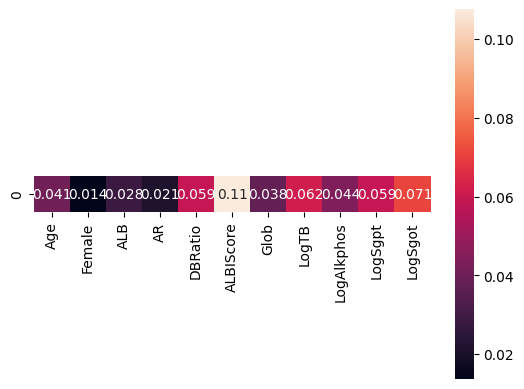

In [69]:
sns.heatmap(Imatt, annot = True, square = True)

In [70]:
data_fs = data_fs.drop(columns = ["Female", "ALB", "AR"])

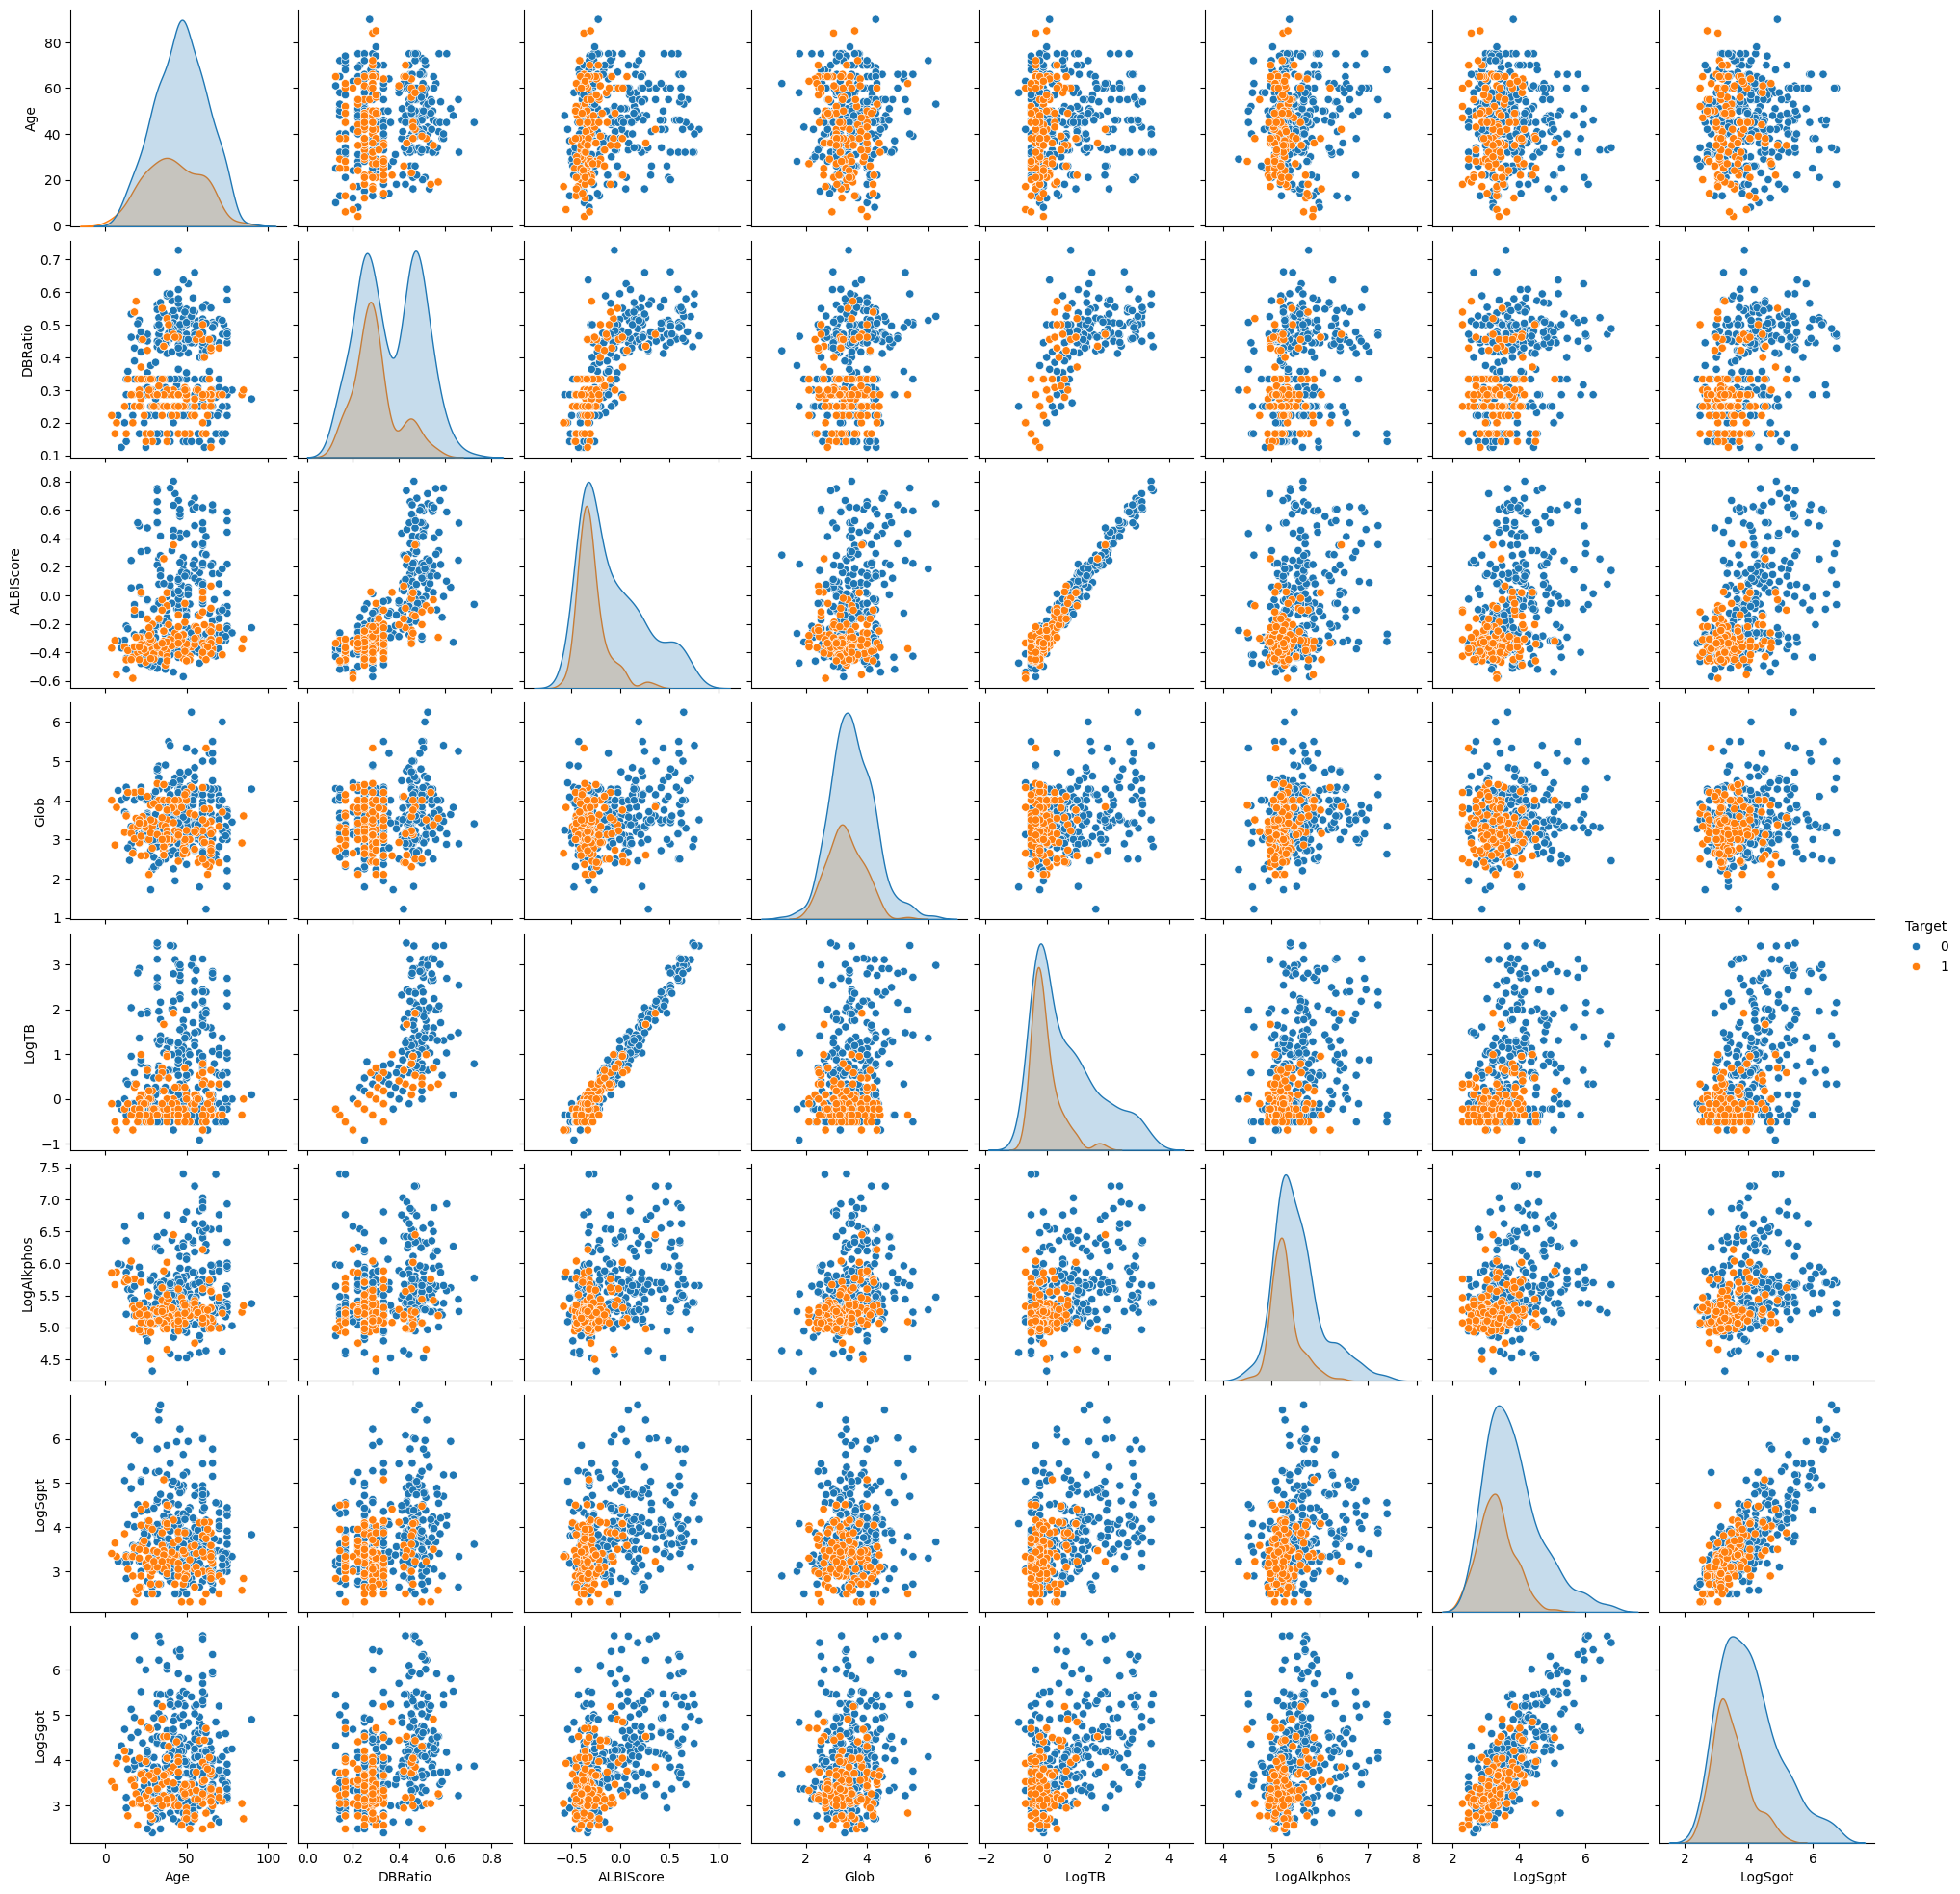

In [72]:
sns.pairplot(data_fs, hue = "Target")

# 7. Saving data and preprocessing the test set

In [ ]:
data_fs.index = data_v3.index

# Categories at the end!
data_fs = data_fs.drop(columns = ["Target"])
data_fs['Target'] = data_v3.Target
data_fs.head()

In [ ]:
data_fs.isna().value_counts()

In [ ]:
data_fs.to_csv("preprocess_train_v4.csv", index = False, header = False)

In [ ]:
test_data = read_csv("test_data_ILDS.csv", delimiter = ',', header = None)
test_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
test_data['Female'] = test_data['Female'].astype('category')

# Feature extraction
test_data["DBRatio"] = test_data["DB"] / test_data["TB"]
test_data['ALBIScore'] = 0.66 * np.log10(test_data.TB) - 0.0852 * test_data.ALB 
test_data['Glob'] = test_data["ALB"] / test_data["AR"]

# Transformations
test_data_v2 = test_data.copy().drop(columns = ["TB", "DB", "Alkphos", "Sgpt", "Sgot", "TP"])
test_data_v2["LogTB"] = np.log(test_data["TB"])
test_data_v2["LogAlkphos"] = np.log(test_data["Alkphos"])
test_data_v2["LogSgpt"] = np.log(test_data["Sgpt"])
test_data_v2["LogSgot"] = np.log(test_data["Sgot"])

# Removing variables
test_data_v2 = test_data_v2.drop(columns = ["Female", "AR", "ALB"])

test_data_v2.to_csv('preprocess_test_v4.csv', index = False, header = False)
test_data_v2.head()

In [ ]:
data_fs.describe()

In [ ]:
test_data_v2.describe()

In [ ]:
test_data_v2.isna().value_counts()

In [ ]:
data_fs.columns

## Experimental: Using principal components

Some of the principal components might impose clearer separations between the sick and healthy patients. Indeed, we can see that practically only the first two principal components and the sixth component allow us to separate the data well enough (especially the first component), while the others might make slight improvements but are not very significant.

In [ ]:
data_fs = data_fs.drop(columns = ["Female", "Target"])
U = plot_PCA(data_fs, data_v3.Target, axes = (0, 1, 2), plot_3D = False)

In [ ]:
X_pca = data_fs @ U

n = 1000
mi = mutual_info_regression(data_fs, data_v3.Target, n_neighbors = 3)
for _ in range(1, n):
    mi += mutual_info_regression(data_fs, data_v3.Target, n_neighbors = 3)
mi = mi / n
columns = [f'PC {i}' for i in range(1, 9)]
Imatt = pd.DataFrame(data = mi.reshape((1, 8)), columns = columns)
sns.heatmap(Imatt, annot=True)

In [ ]:
data_minimal_num = data_minimal.drop(columns = ["Female", "Target"])
data_v3_pca = data_minimal_num @ U
data_v3_pca.columns = columns
data_v3_pca["Female"] = data_fs.Female
data_v3_pca["Target"] = data_fs.Target
data_v3_pca.head()

In [ ]:
data_v3_pca.to_csv("pca_train_fs.csv", index = False, header = False)

In [ ]:
test_minimal_num = test_minimal.drop(columns = ["Female"])
test_pca = test_minimal_num @ U
test_pca["Female"] = scaled_test_fs.Female
test_pca.to_csv("pca_test_fs.csv", index = False, header = False)

## Experimental: Undersampling

In [ ]:
from imblearn.under_sampling import NearMiss

undersampler = NearMiss(sampling_strategy = 0.5)
X_undersamp, y_undersamp = undersampler.fit_resample(scaled_data, data_v3.Target)
X_undersamp.describe()

In [ ]:
y_undersamp.value_counts()

In [ ]:
U = plot_PCA(X_undersamp.drop(columns = "Female"), y_undersamp)
X_under_PCA = X_undersamp.drop(columns = "Female") @ U

In [ ]:
X_undersamp["Target"] = y_undersamp
X_undersamp.head()

In [ ]:
X_undersamp.to_csv('undersampled_train.csv', index = False, header = False)
X_undersamp.columns

# Final. Test preprocessing

In [ ]:
test_data = read_csv("test_data_ILDS.csv", delimiter=',', header=None)
test_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
test_data['Female'] = test_data['Female'].astype('category')

test_data["BilRatio"] = test_data["DB"] / test_data["TB"]

test_data_v2 = test_data.copy()

test_data_v2["TB"] = np.log(test_data["TB"])
test_data_v2["DB"] = np.log(test_data["DB"])
test_data_v2["Alkphos"] = np.log(test_data["Alkphos"])
test_data_v2["Sgpt"] = np.log(test_data["Sgpt"])
test_data_v2["Sgot"] = np.log(test_data["Sgot"])

test_data_v2.to_csv('preprocess_test_v3.csv', index = False, header = False)
test_data_v2.describe()